## Лабораторна робота №2.



Оцінювання даної роботи буде ураховувати якість ваших візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.

Під час виконання вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.






Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою [titanic.csv](https://gist.github.com/michhar/2dfd2de0d4f8727f873422c5d959fff5).  
Цей датасет ви вже використовували в лабораторній роботі №1 ;)  
  
  ```NB:побудовані графіки та гістограми мають бути змістовними і візуально зрозумілими.```
  
  
  

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

dataset = pd.read_csv("/content/sample_data/titanic.csv")

**Задача 1:** Який відсоток виживання серед чоловіків / жінок?

In [3]:
gender_survival = dataset.groupby("Sex")["Survived"].mean() * 100
print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


**Задача 2:** Відтворіть ці графіки  
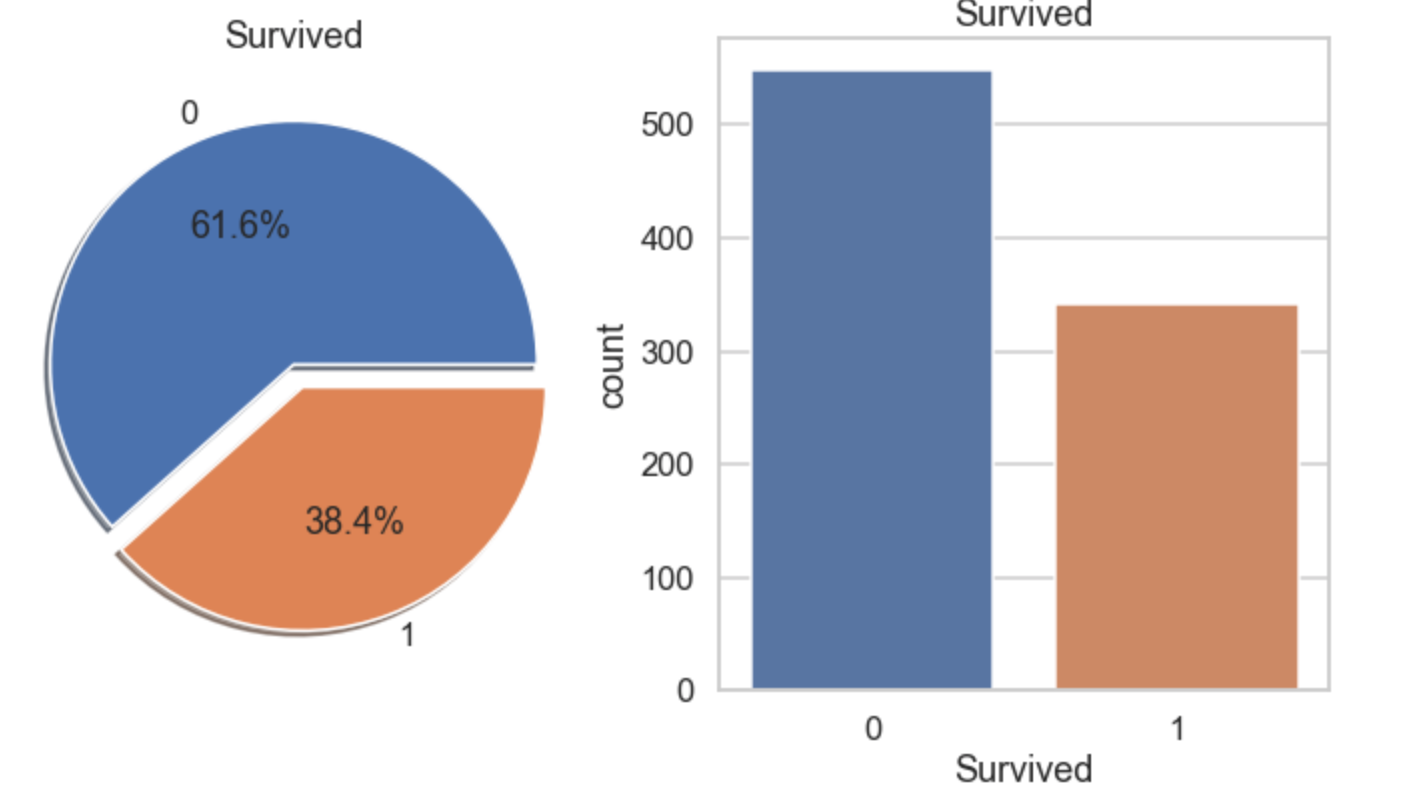


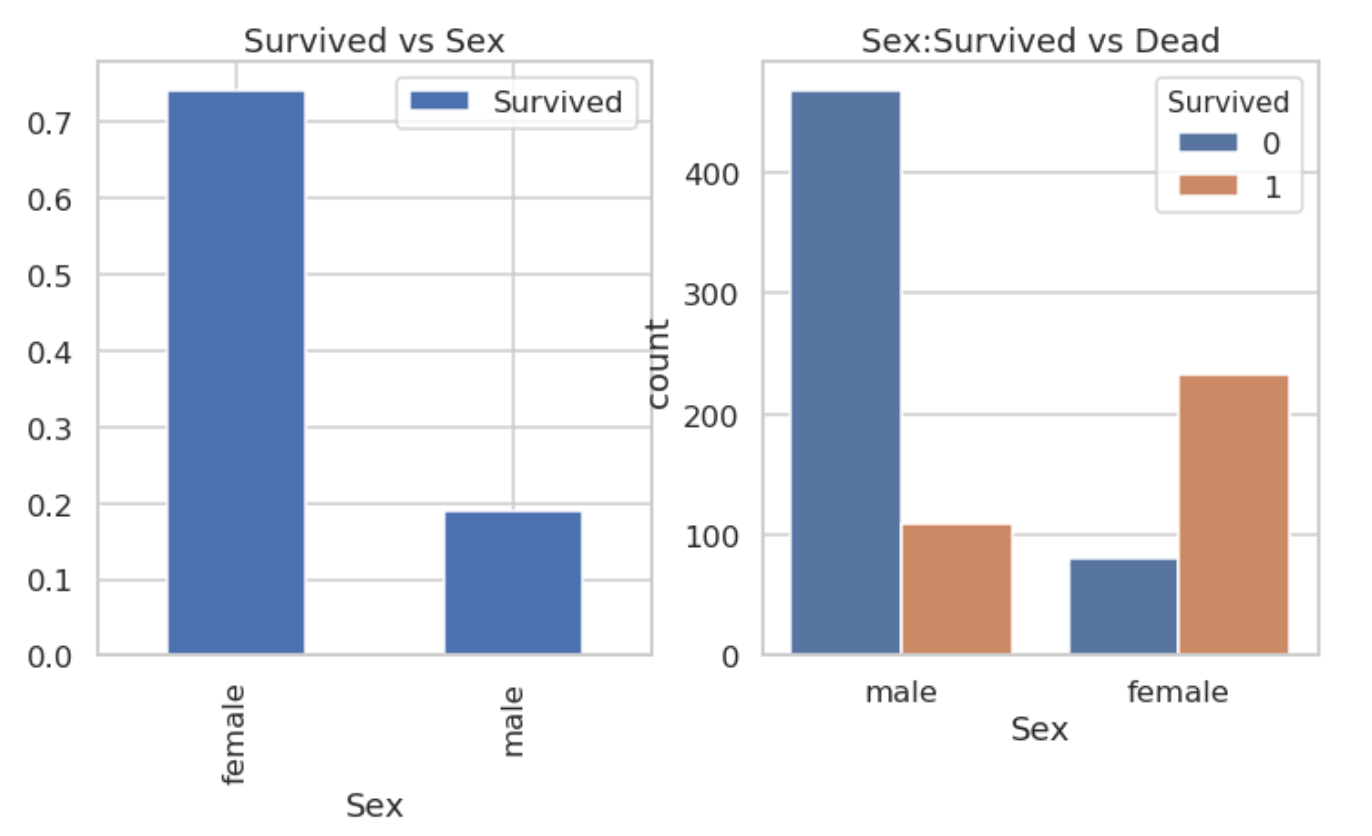

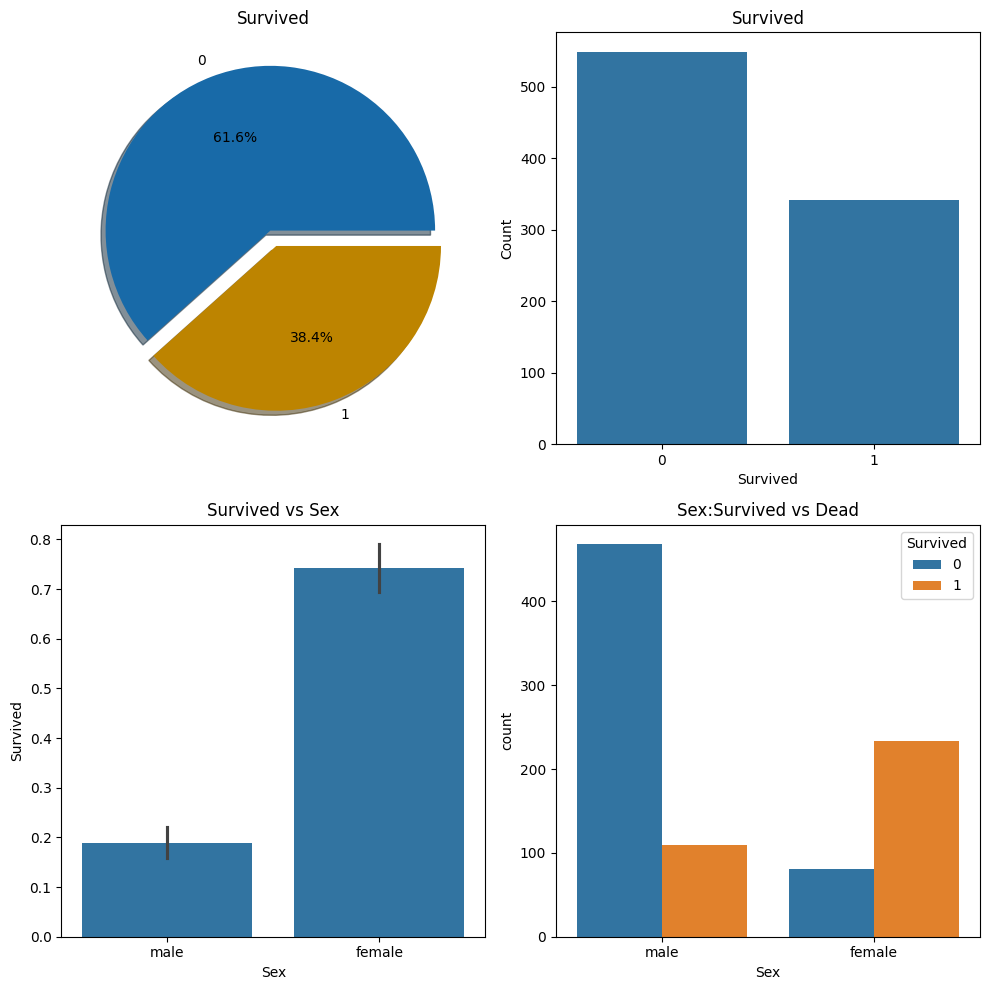

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

survival_counts = dataset['Survived'].value_counts()
labels = ['0', '1']
axes[0, 0].pie(survival_counts, labels=labels, autopct='%1.1f%%', startangle=0, colors=['#186aa8', '#bd8400'], shadow=True, explode=(0.05, 0.05))
axes[0, 0].set_title('Survived')


sns.countplot(x="Survived", data=dataset, ax=axes[0, 1])
axes[0, 1].set_title("Survived")
axes[0, 1].set_ylabel("Count")


sns.barplot(x="Sex", y="Survived", data=dataset, ax=axes[1, 0])
axes[1, 0].set_title("Survived vs Sex")

sns.countplot(x="Sex", hue="Survived", data=dataset, ax=axes[1, 1])
axes[1, 1].set_title("Sex:Survived vs Dead")

plt.tight_layout()
plt.show()


**Задача 3:** Скільки пропущених значень в датасеті по кожній із змінних?

In [5]:

dataset.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Задача 4:** Назвіть найпопулярніше **жіноче** ім'я на кораблі.

In [6]:
def popular_name(sex):
    names = dataset[dataset['Sex'] == sex]['Name'].str.extract(r'\((\w+)')
    return names.value_counts().idxmax()

female_name = popular_name('female')
print('The most popular name:', female_name)

The most popular name: ('Anna',)


**Задача 5:** Назвіть найпопулярніше **чоловіче** ім'я на кораблі.

In [7]:
def popular_name(sex):
    names = dataset[dataset['Sex'] == sex]['Name']
    name = names.str.extract(r'(\w+)')
    return name.value_counts().idxmax()

male_name = popular_name('male')
print('The most popular male name:', male_name)


The most popular male name: ('Panula',)


**Задача 6:** Побудуйте діаграми співвідношення загиблих та виживших за інформацією про те, квитки якого класу були у пасажирів.
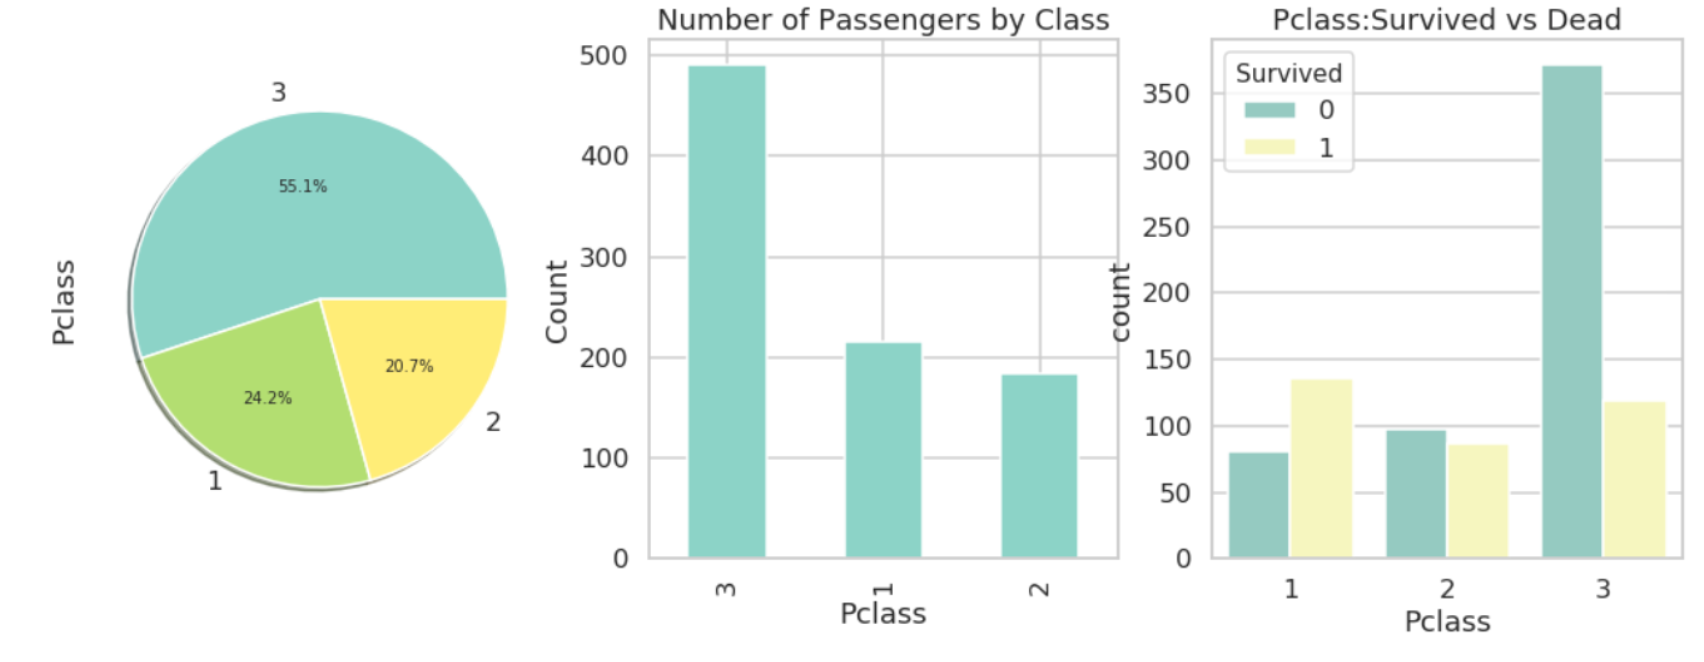

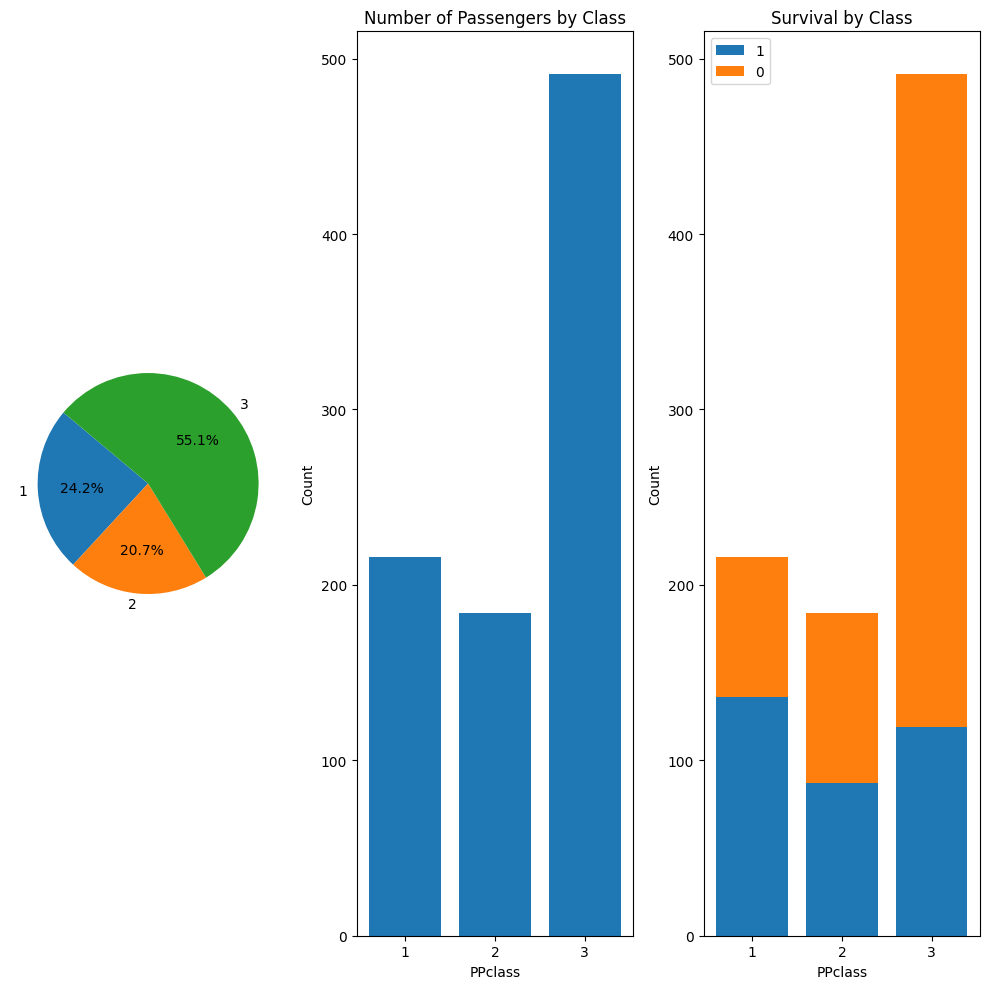

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(10, 10))
class_counts = dataset['Pclass'].value_counts().sort_index()
survived_counts = dataset[dataset['Survived'] == 1]['Pclass'].value_counts().sort_index()
dead_counts = class_counts - survived_counts
labels = ['1', '2', '3']
axes[0].pie(class_counts, labels=labels, autopct='%1.1f%%', startangle=140)


axes[1].bar(labels, class_counts)
axes[1].set_title('Number of Passengers by Class')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('PPclass')


axes[2].bar(labels, survived_counts, label='1')
axes[2].bar(labels, dead_counts, bottom=survived_counts, label='0')
axes[2].set_title('Survival by Class')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('PPclass')
axes[2].legend()

plt.tight_layout()
plt.show()

Згідно з продемонстованих графіків, можемо побачити, що 61.6 % людей вижили, та 38.4 % загинули. Також смертність чоловіків на багато більша ніж жіноча.

**Задача 7:** Побудуйте наступні графіки та опишіть, що власне на них відображається.  
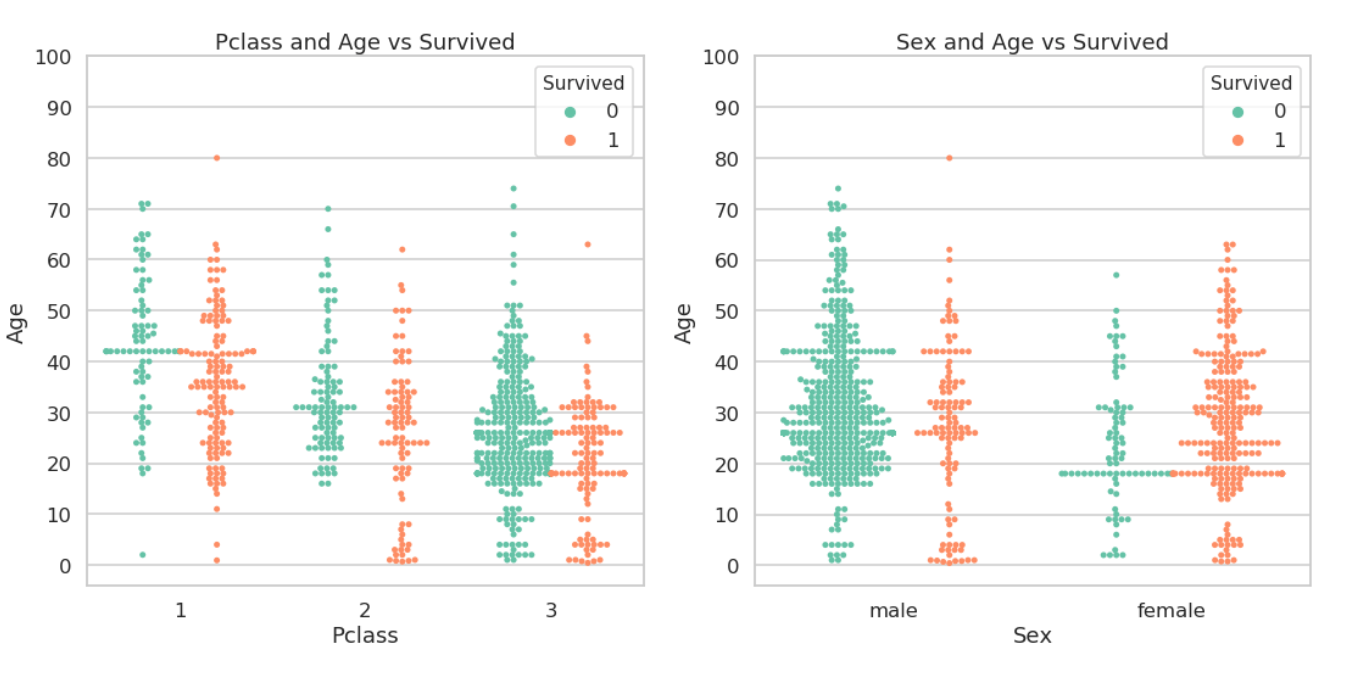![image.png](attachment:51486806-bd5d-4ae3-b95a-548aebf83de2.png)

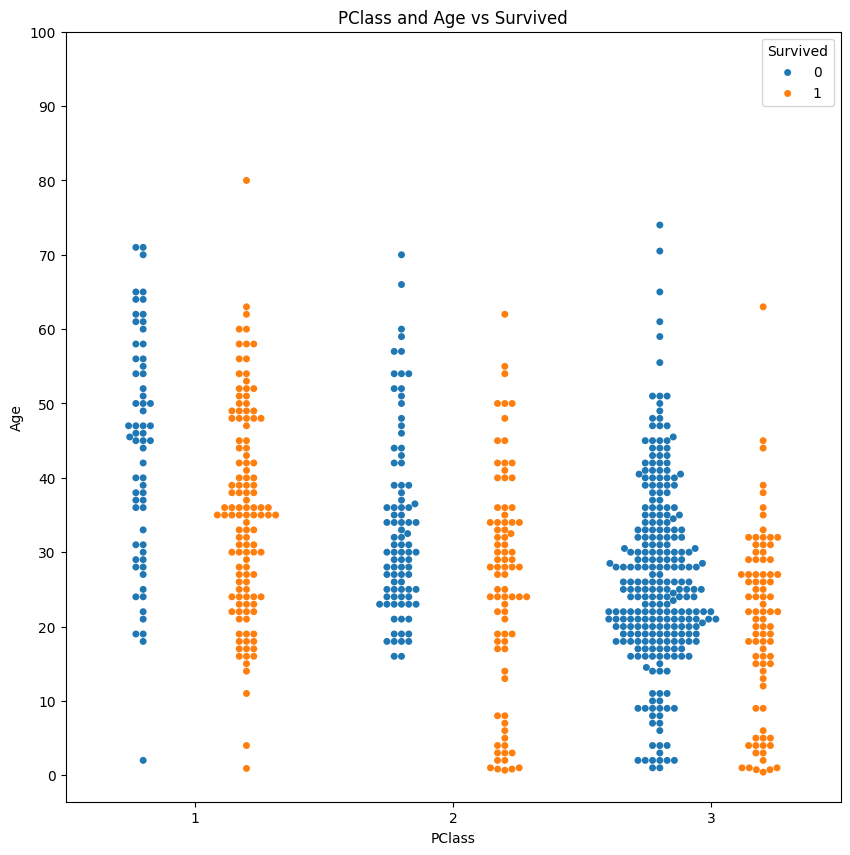

In [9]:
fig, axes = plt.subplots(1, figsize=(10, 10))

sns.swarmplot(data=dataset, x="Pclass", y="Age", hue="Survived", dodge=True)


plt.title("PClass and Age vs Survived")
plt.xlabel("PClass")
plt.ylabel("Age")
plt.yticks(np.arange(0, 101, 10))

plt.legend(title="Survived", labels=["0", "1"])
plt.show()

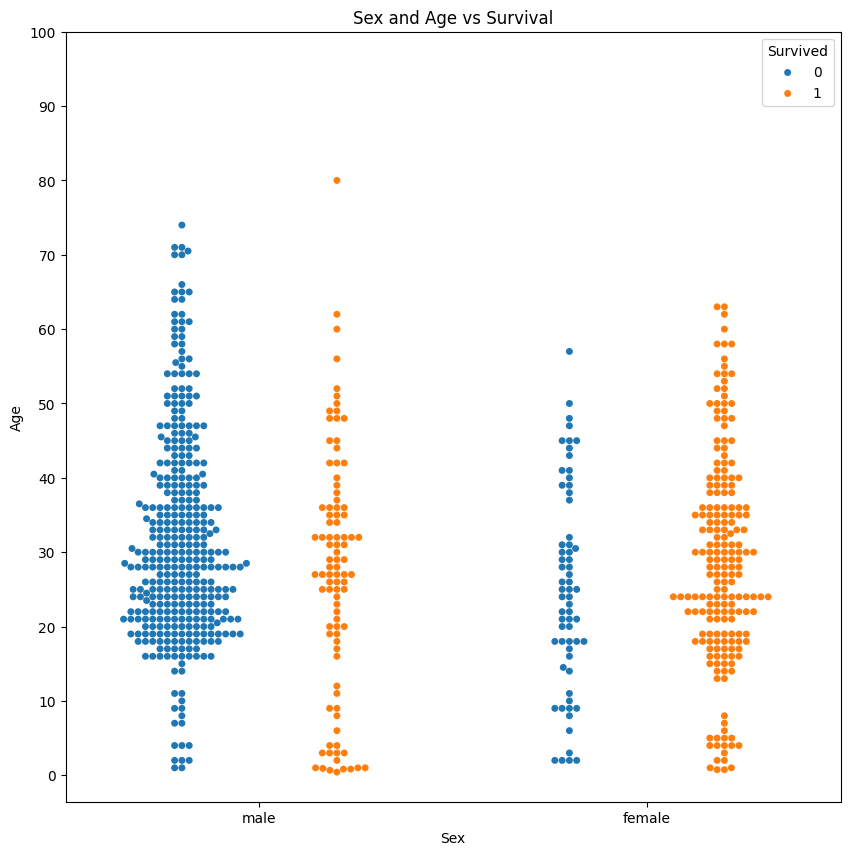

In [10]:
plt.figure(figsize=(10, 10))
sns.swarmplot(data=dataset, x="Sex", y="Age", hue="Survived", dodge=True)

plt.title("Sex and Age vs Survival")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.yticks(np.arange(0, 101, 10))

plt.legend(title="Survived", labels=["0", "1"])
plt.show()

Графік показує розподіл віку (Age) за статтю (Sex)

**Задача 8** Побудуйте наступні діаграми розподілів:  

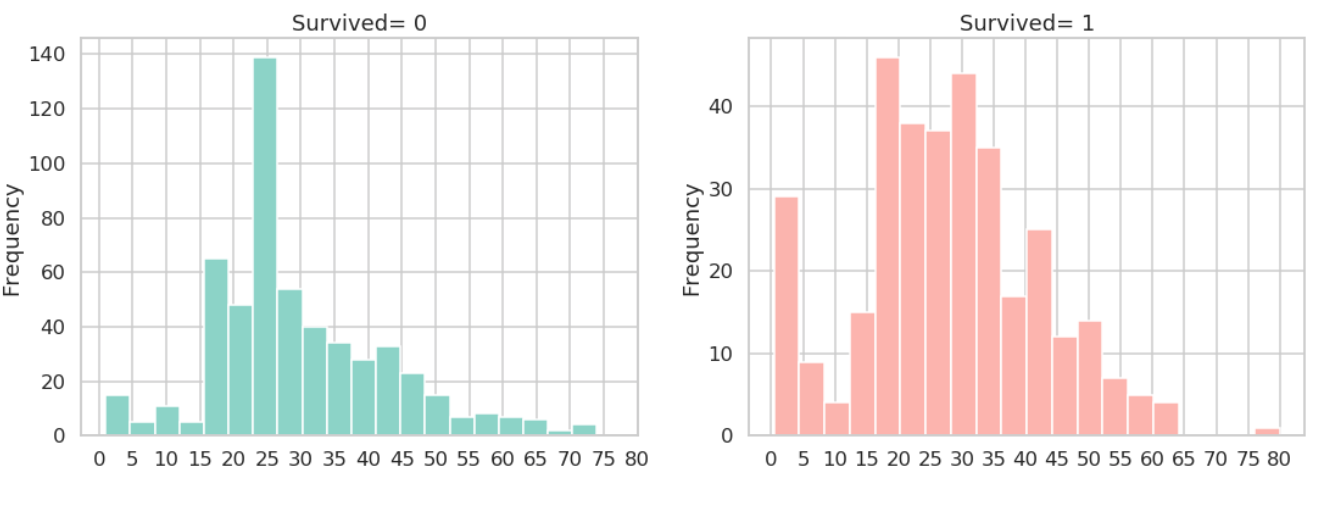



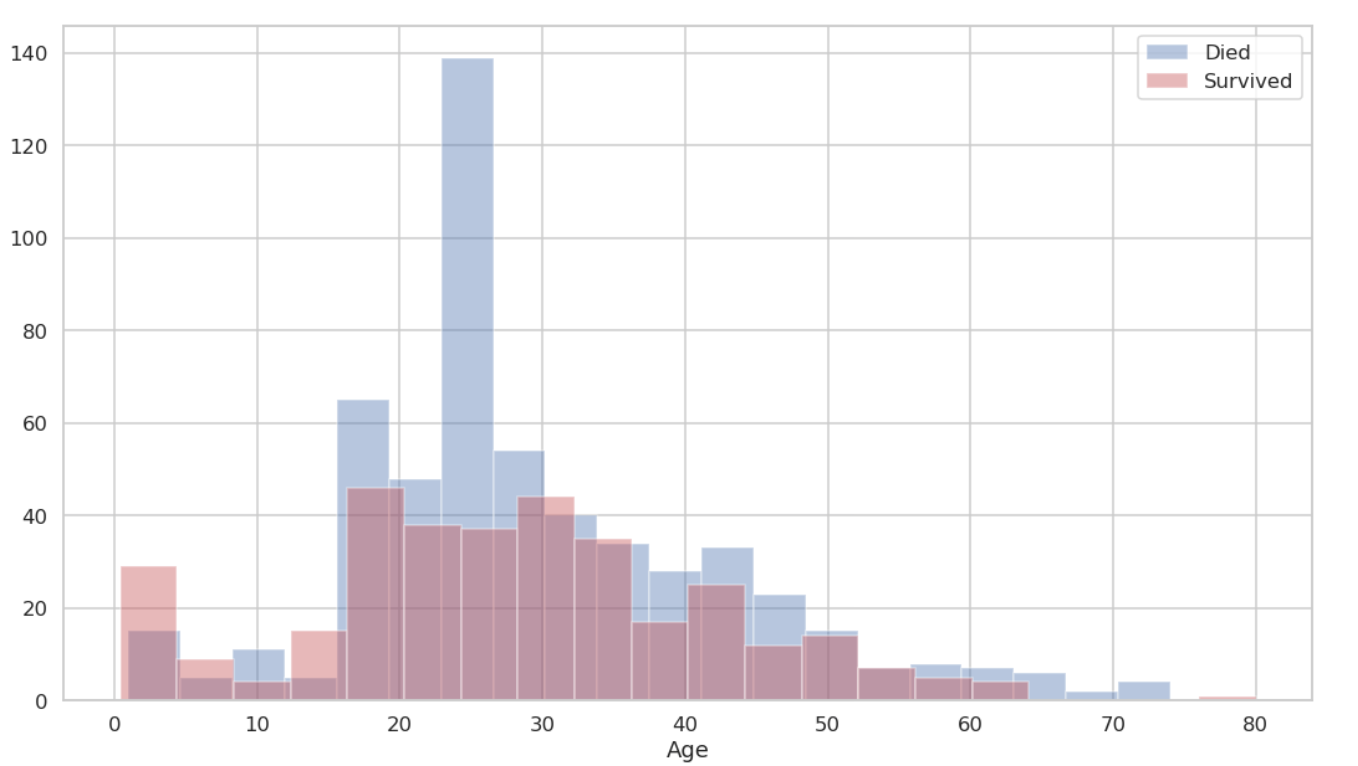

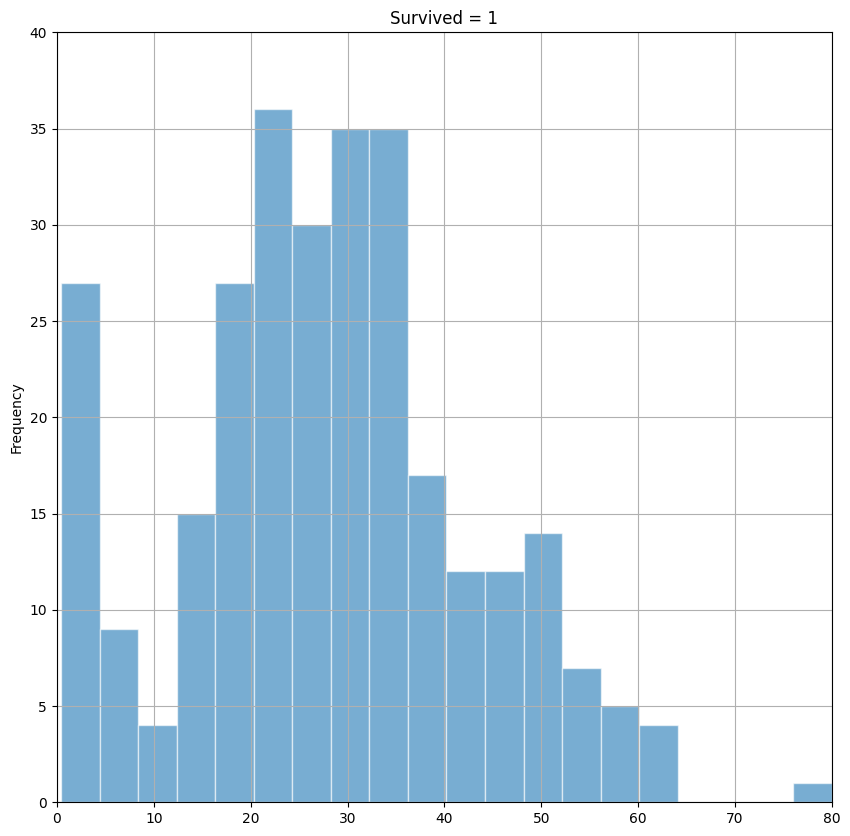

In [11]:
plt.figure(figsize=(10,10))

sur_data = dataset[dataset['Survived'] == 1]
plt.hist(sur_data['Age'].dropna(), bins=20, alpha=0.6, edgecolor='1')
plt.ylabel("Frequency")
plt.title("Survived = 1")
plt.grid(True)
plt.xlim(0, 80)
plt.ylim(0, 40)

plt.show()

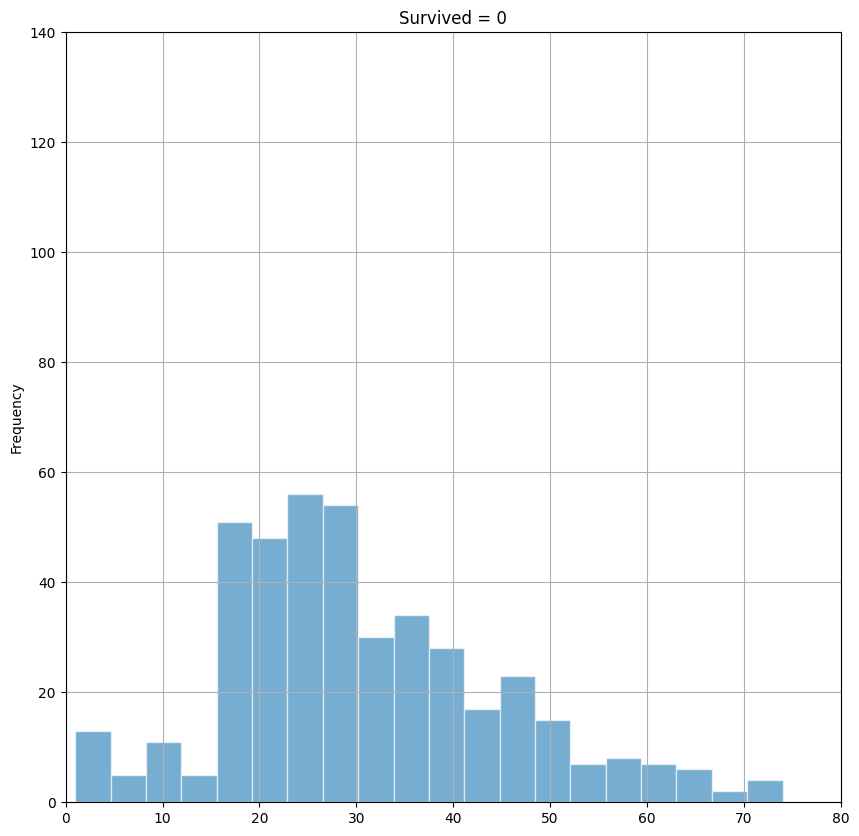

In [12]:
plt.figure(figsize=(10,10))

sur_data = dataset[dataset['Survived'] == 0]
plt.hist(sur_data['Age'].dropna(), bins=20, alpha=0.6, edgecolor='1')
plt.ylabel("Frequency")
plt.title("Survived = 0")
plt.grid(True)
plt.xlim(0, 80)
plt.ylim(0, 140)

plt.show()

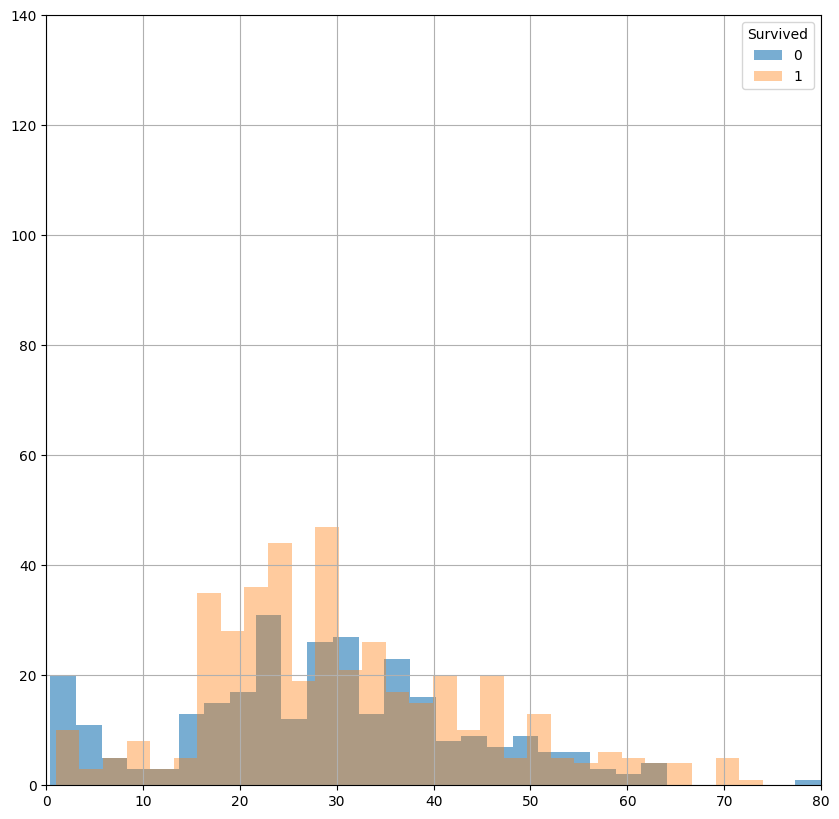

In [13]:
plt.figure(figsize=(10, 10))

sur_passenger = dataset[dataset['Survived'] == 1]
dead_passengers = dataset[dataset['Survived'] == 0]

plt.hist(sur_passenger['Age'].dropna(), bins=30, alpha=0.6)
plt.hist(dead_passengers['Age'].dropna(), bins=30, alpha=0.4)
plt.grid(True)
plt.xlim(0, 80)
plt.ylim(0, 140)

plt.legend(title="Survived", labels=["0", "1"])
plt.show()

Гістограми не є достатніми для повного статистичного аналізу.


**Задача 9:** Побудуйте наступні діаграми та проведіть аналітику шансів на виживання серед пасажирів:  
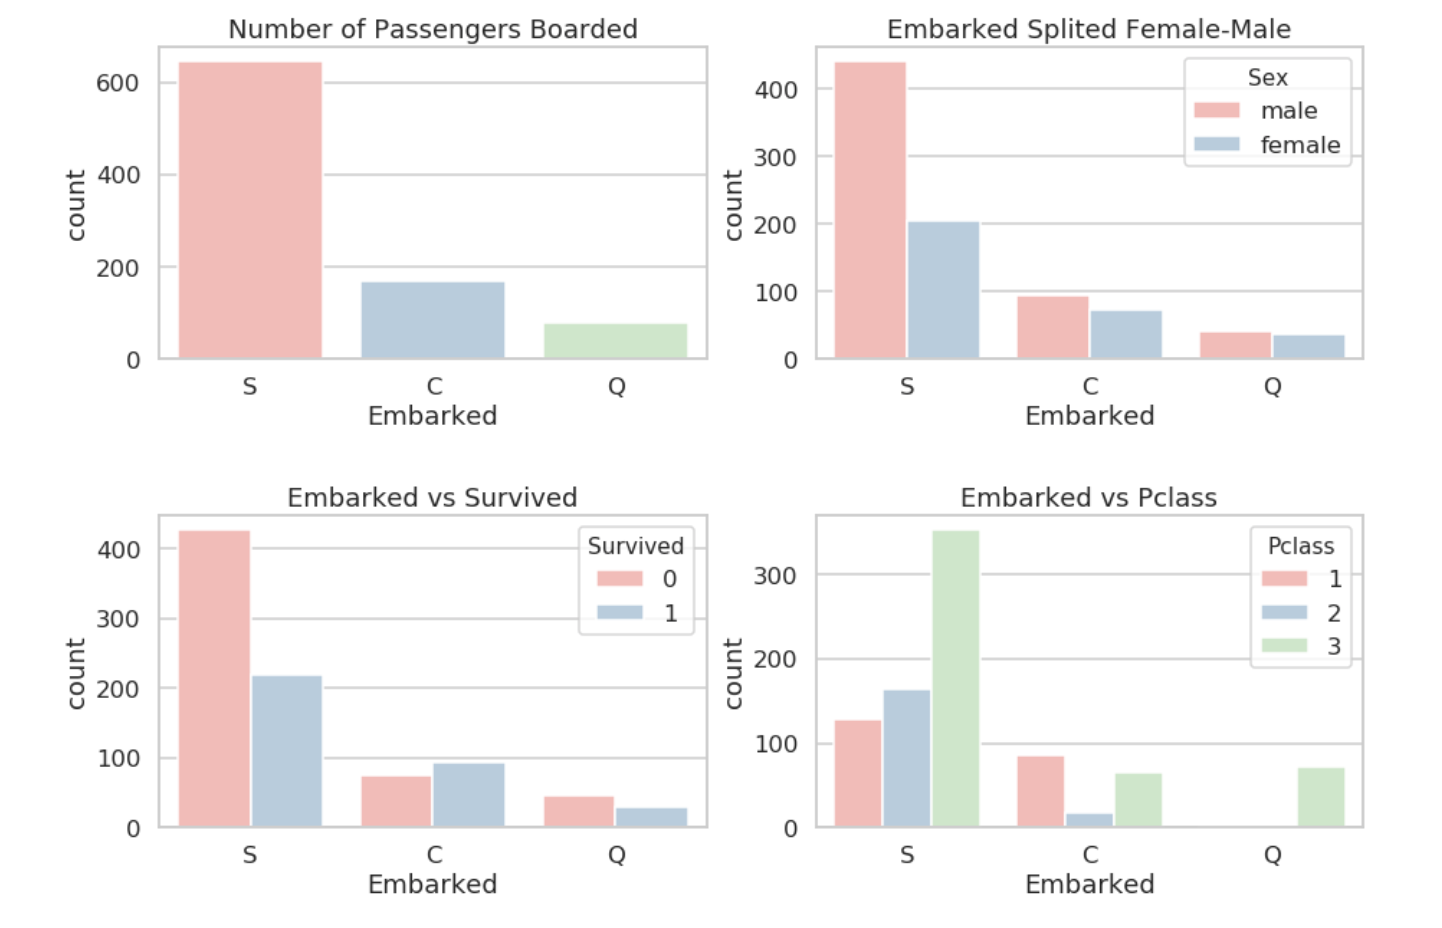

<ipython-input-16-d9c41d39a037>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=embarked_number.index, y=embarked_number.values, ax=axes[0, 0], palette="pastel")


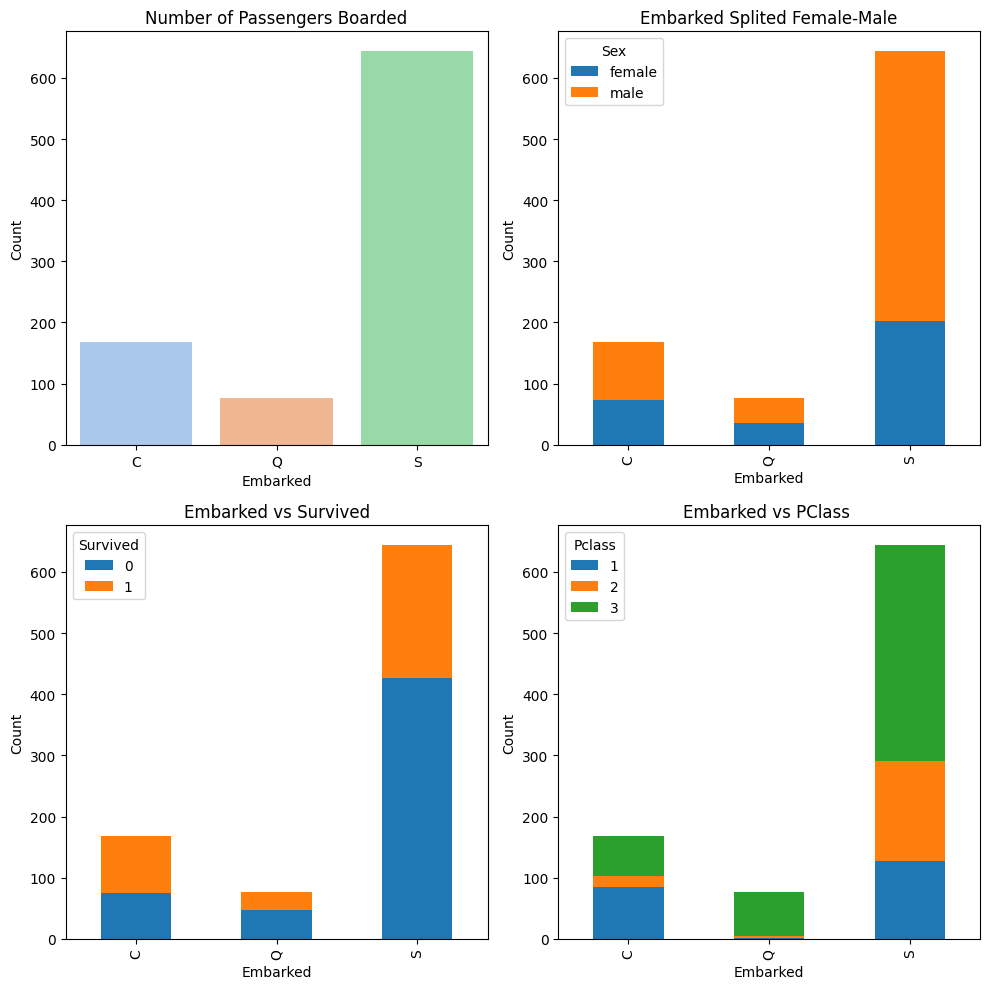

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

embarked_number = dataset['Embarked'].value_counts().sort_index()
embarked_splited = dataset.groupby(['Embarked', 'Sex']).size().unstack()
embarked_survived = dataset.groupby(['Embarked', 'Survived']).size().unstack()
embarked_Pclass = dataset.groupby(['Embarked', 'Pclass']).size().unstack()

sns.barplot(x=embarked_number.index, y=embarked_number.values, ax=axes[0, 0], palette="pastel")
axes[0, 0].set_title("Number of Passengers Boarded")
axes[0, 0].set_xlabel("Embarked")
axes[0, 0].set_ylabel("Count")

embarked_splited.plot(kind='bar', stacked=True, ax=axes[0, 1])
axes[0, 1].set_title("Embarked Splited Female-Male")
axes[0, 1].set_xlabel("Embarked")
axes[0, 1].set_ylabel("Count")

embarked_survived.plot(kind='bar', stacked=True, ax=axes[1, 0])
axes[1, 0].set_title("Embarked vs Survived")
axes[1, 0].set_xlabel("Embarked")
axes[1, 0].set_ylabel("Count")

embarked_Pclass.plot(kind='bar', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title("Embarked vs PClass ")
axes[1, 1].set_xlabel("Embarked")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

***Завдача 10** Побудуйте діаграму розподілу ```вартості квитка``` відповідно до якого классу належіть пасажир.

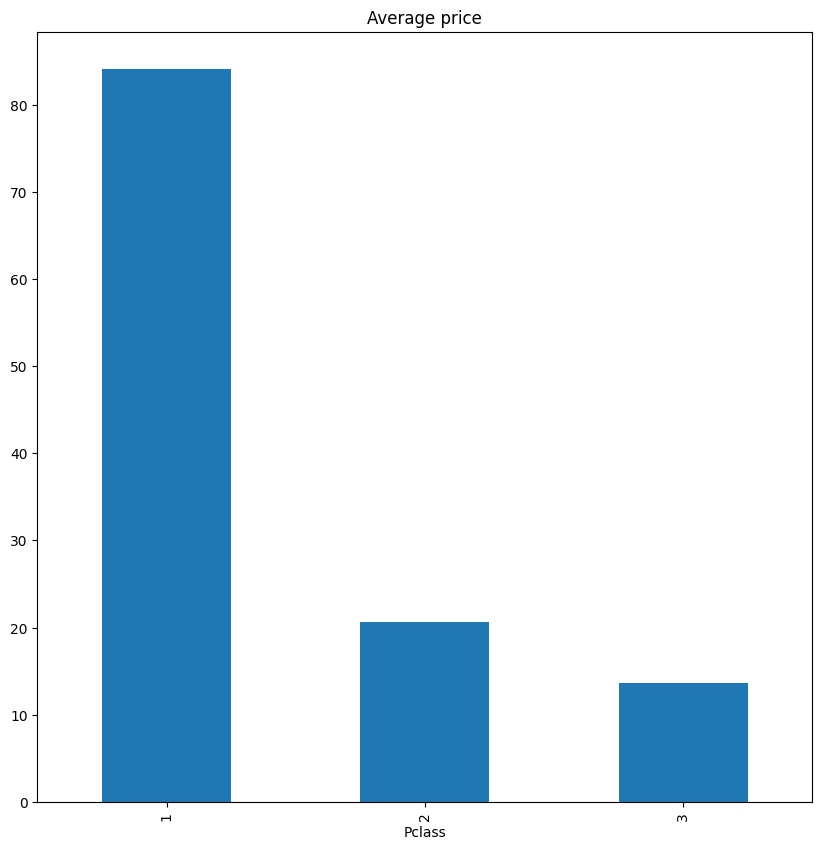

In [15]:
fig, axes = plt.subplots(figsize=(10, 10))

price_class = dataset.groupby(['Pclass'])['Fare'].mean()
price_class.plot.bar(price_class)
plt.title('Average price')
plt.show()
